In [1]:
#Loading in Packages and Data

#Importing Packages
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import xarray as xr
import os; import time
import pickle
import h5py
###############################################################
def coefs(coefficients,degree):
    coef=coefficients
    coefs=""
    for n in range(degree, -1, -1):
        string=f"({coefficients[len(coef)-(n+1)]:.1e})"
        coefs+=string + f"x^{n}"
        if n != 0:
            coefs+=" + "
    return coefs
###############################################################

# #Importing Model Data
    
# dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
# data=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_test7tundra-7_062217.nc') #***
# true_time=data['time']
# # parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_test5tundra-7_062217.nc') #***
# times=data['time'].values/(1e9 * 60); times=times.astype(float);
# Np_str='125e3'
# #Restricts the timesteps of the data from timesteps0 to 140
# data=data.isel(time=np.arange(0,140+1))
# # parcel=parcel.isel(time=np.arange(0,140+1))
# res='1km'

dir='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
data=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_1km_1e6.nc') #***
true_time=data['time']
parcel=xr.open_dataset(dir+'../cm1r20.3/run/cm1out_pdata_1km_1e6.nc') #***
times=data['time'].values/(1e9 * 60); times=times.astype(float);
Np_str='1e6'
#Restricts the timesteps of the data from timesteps0 to 140
res='1km'
index_adjust=0
ocean_fraction=0.25


# #uncomment if using 250m data
# #Importing Model Data
# check=False
# dir2='/home/air673/koa_scratch/'
# data=xr.open_dataset(dir2+'cm1out_250m.nc') #***
# # # parcel=xr.open_dataset(dir2+'cm1out_pdata_250m.nc') #***

# # Restricts the timesteps of the data from timesteps0 to 140
# data=data.isel(time=np.arange(0,400+1))
# # # parcel=parcel.isel(time=np.arange(0,400+1))
# res='250m'

In [60]:
import sys
dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/DCI-Project/'
path=dir2+'../Functions/'
sys.path.append(path)

import NumericalFunctions
from NumericalFunctions import * # import NumericalFunctions 
import PlottingFunctions
from PlottingFunctions import * # import PlottingFunctions


# # Get all functions in NumericalFunctions
# import inspect
# functions = [f[0] for f in inspect.getmembers(NumericalFunctions, inspect.isfunction)]
# functions

# # Get all functions in NumericalFunctions
# import inspect
# functions = [f[0] for f in inspect.getmembers(PlottingFunctions, inspect.isfunction)]
# functions

In [73]:
# Reading Back Data Later
##############
import h5py
dir2=dir+'Project_Algorithms/Lagrangian_Binary_Array/'
in_file=dir2+f'lagrangian_binary_array_{res}_{Np_str}.h5'
# in_file=dir2+f'lagrangian_binary_array_{res}_{Np_str}_TEST.h5'
with h5py.File(in_file, 'r') as f:
    # Load the dataset by its name
    A_g = f['A_g'][:]
    A_c = f['A_c'][:]

    # W = f['W'][:]
    # QCQI = f['QCQI'][:]
    Z = f['Z'][:]
    Y = f['Y'][:]
    X = f['X'][:]

# #Making Time Matrix
# rows, cols = A.shape[0], A.shape[1]
# T = np.arange(rows).reshape(-1, 1) * np.ones((1, cols), dtype=int)

In [62]:
#READING BACK IN
mins_thresh=5
# mins_thresh=10
dir3=dir+f'Project_Algorithms/Entrainment/processed_binary_arrays_'+str(mins_thresh)+f'mins_{res}_{Np_str}.h5'
with h5py.File(dir3, 'r') as h5file:
    A_g_Processed = h5file['A_g_Processed'][:]
    A_c_Processed = h5file['A_c_Processed'][:]

In [74]:
# #DOMAIN SUBSETTING
# ocean_percent=2/8

# left_to_coast=data['xh'][0]+(data['xh'][-1]-data['xh'][0])*ocean_percent
# where_coast_xh=np.where(data['xh']>=left_to_coast)[0][0]#-25
# where_coast_xf=np.where(data['xf']>=left_to_coast)[0][0]#-25
# end_xh=len(data['xh'])-1-50
# end_xf=len(data['xf'])-1-50

# print(f'x in {0}:{where_coast_xh-1} FOR SEA')
# print(f'x in {where_coast_xh}:{end_xh} FOR LAND')
# # t_end=78 
# # if res=='250m':t_end=410
# # print(f't in {0}:{t_end} (6.5 hours)')
# t_start=36 
# print(f't in {t_start}:end (8 hours)')


# #CORRECTING LAGRANGIAN BINARY ARRAYS
# one=X<where_coast_xh
# two=X>end_xh
# where=np.where(one|two)
# A_g[where]=0
# A_c[where]=0
# # A_g_Processed[where]=0
# # A_c_Processed[where]=0

x in 0:127 FOR SEA
x in 128:461 FOR LAND
t in 36:end (8 hours)


In [50]:
###########################################################################################################################################################################

In [51]:
#ENTRAINMENT/DETRAINMENT
########################################################################################################

In [26]:
#constants
Cp=1004 #Jkg-1K-1
Cv=717 #Jkg-1K-1
Rd=Cp-Cv #Jkg-1K-1
eps=0.608

Lx=data['xf'][-1].item()-data['xf'][0].item()#*1000 #x length (km)
Ly=data['yf'][-1].item()-data['yf'][0].item()#*1000 #y length (km)
Np=len(parcel['xh']) #number of lagrangian parcles
dt=data['time'][1].item()/1e9 #sec
dx=(data['xf'][1].item()-data['xf'][0].item())*1e3 #meters
dy=(data['yf'][1].item()-data['yf'][0].item())*1e3 #meters
xs=data['xf'].values*1000
ys=data['yf'].values*1000
zs=data['zf'].values*1000

def zf(z):
    k=z #z is the # level of z
    out=data['zf'].values[k]*1000
    return out
# def rho(x,y,z,t):
#     p=data['prs'].isel(xh=x,yh=y,zh=z,time=t).item()
#     p0=101325 #Pa
#     theta=data['th'].isel(xh=x,yh=y,zh=z,time=t).item()
#     T=theta*(p/p0)**(Rd/Cp)
#     qv=data['qv'].isel(xh=x,yh=y,zh=z,time=t).item()
#     # Tv=T*(1+eps*qv)
#     Tv=T*(eps+qv)/(eps*(1+qv))
#     rho = p/(Rd*Tv)
#     out=rho
#     return out
rho_data=data['rho'].data
def rho(x,y,z,t):
    # out=data['rho'].isel(xh=x,yh=y,zh=z,time=t).item()
    out=rho_data[t,z,y,x]
    return out
def m(t):
    m=0
    #triple sum
    for k in range(len('zh')):
        for j in range(len('yh')):
            for i in range(len('xh')):
                rho_out=rho(i,j,k,t)
                m+=rho_out*(zf(k+1)-zf(k))
    #triple sum
    m=m*dx*dy/Np
    out=m
    return out

In [76]:
#TURN PROCESSING ON OR OFF
PROCESSING=False
# PROCESSING=True

def ed(A,z,t,type):    
    #Essential A_t-A_(t-1)
    D=A[t,:]-A[t-1,:]

    #Get Z Locations
    zs=Z[t,:]
    
    #Essentially the I function
    z_ind=np.where(zs==z)
    A_z=D[z_ind]
    
    #Esentially the H function
    if type=='e':
        A_sum=np.sum(A_z[A_z>0]) #entrainment
    if type=='d':
        A_sum=-np.sum(A_z[A_z<0]) #detrainment

    #REMOVING THE FIRST TIMESTEP
    if t==0:
        A_sum=0

    # #CONSTANT (APPLIED AFTER CALCULATION)
    # ############
    # m_out=m(t)
    # dz=zf(z+1)-zf(z)
    # constant=(m_out/Lx/Ly/dz/dt) 
    # # constant=1 #TESTING
    # A_sum*=constant


    return A_sum

#creates 2d storage array
tlen=len(data['time'])
zlen=len(data['zh'])
profile_array_e_g=np.zeros((tlen,zlen))
profile_array_d_g=np.zeros((tlen,zlen))
profile_array_e_c=np.zeros((tlen,zlen))
profile_array_d_c=np.zeros((tlen,zlen))

#Adding to Profile Array
import itertools
ts = range(0, len(data['time']))  # ts from 0 to 140
zs = range(0, len(data['zh']))   # zs from 0 to 34
for count, (t, z) in enumerate(itertools.product(ts, zs)):
    if np.mod(count,1000)==0: print(f'{count*100/len(ts)/len(zs):.2f}%')

    #GENERAL
    if PROCESSING==False:
        A_sum_g=ed(A_g, z,t,type='e'); profile_array_e_g[t,z]+=A_sum_g
        A_sum_g=ed(A_g, z,t,type='d'); profile_array_d_g[t,z]+=A_sum_g
    elif PROCESSING==True:
        A_sum_g=ed(A_g_Processed, z,t,type='e'); profile_array_e_g[t,z]+=A_sum_g
        A_sum_g=ed(A_g_Processed, z,t,type='d'); profile_array_d_g[t,z]+=A_sum_g

    #CLOUDY
    if PROCESSING==False:
        A_sum_c=ed(A_c, z,t,type='e'); profile_array_e_c[t,z]+=A_sum_c
        A_sum_c=ed(A_c, z,t,type='d'); profile_array_d_c[t,z]+=A_sum_c
    elif PROCESSING==True:
        A_sum_c=ed(A_c_Processed, z,t,type='e'); profile_array_e_c[t,z]+=A_sum_c
        A_sum_c=ed(A_c_Processed, z,t,type='d'); profile_array_d_c[t,z]+=A_sum_c

#SAVING
if PROCESSING==False:
    dir3=dir+f'Project_Algorithms/Entrainment/2D_entrainmentdetrainment_profiles_{res}_{Np_str}.h5'
if PROCESSING==True:
    dir3=dir+f'Project_Algorithms/Entrainment/2D_entrainmentdetrainment_profiles_PREPROCESSING_{res}_{Np_str}.h5'
with h5py.File(dir3, "w") as h5f:
    h5f.create_dataset("profile_array_e_g", data=profile_array_e_g)
    h5f.create_dataset("profile_array_e_c", data=profile_array_e_c)
    h5f.create_dataset("profile_array_d_g", data=profile_array_d_g)
    h5f.create_dataset("profile_array_d_c", data=profile_array_d_c)
print('done')

0.00%
22.11%
44.23%
66.34%
88.46%
done


In [73]:
# #TESTING
# # Reading Back Data Later
# ##############
# del A_c, A_g
# import h5py
# dir2=dir+'Project_Algorithms/Lagrangian_Binary_Array/'
# in_file=dir2+f'lagrangian_binary_array_{res}_{Np_str}.h5'
# # in_file=dir2+f'lagrangian_binary_array_{res}_{Np_str}_TEST.h5'
# with h5py.File(in_file, 'r') as f:
#     # Load the dataset by its name
#     A_g = f['A_g'][:]
#     A_c = f['A_c'][:]

#     # W = f['W'][:]
#     # QCQI = f['QCQI'][:]
#     Z = f['Z'][:]
#     Y = f['Y'][:]
#     X = f['X'][:]

# # #Making Time Matrix
# # rows, cols = A.shape[0], A.shape[1]
# # T = np.arange(rows).reshape(-1, 1) * np.ones((1, cols), dtype=int)


# def ed(A,z,t,type):    
#     #Essential A_t-A_(t-1)
#     D=A[t,:]-A[t-1,:]

#     #Get Z Locations
#     zs=Z[t,:]
    
#     #Essentially the I function
#     z_ind=np.where(zs==z)
#     A_z=D[z_ind]
    
#     #Esentially the H function
#     if type=='e':
#         A_sum=np.sum(A_z[A_z>0]) #entrainment
#     if type=='d':
#         A_sum=-np.sum(A_z[A_z<0]) #detrainment

#     #REMOVING THE FIRST TIMESTEP
#     if t==0:
#         A_sum=0

#     # #CONSTANT 
#     # ############
#     # m_out=m(t)
#     # dz=zf(z+1)-zf(z)
#     # constant=(m_out/Lx/Ly/dz/dt) 
#     # # constant=1
#     # A_sum*=constant
#     return A_sum

In [164]:
# #TESTING ALGORITHM VS SEPERATE METHOD
# #CLOUDY
# t=90
# zhs=data['zh']
# entrain = []
# detrain = []
# for z in np.arange(len(data['zh'])):
#     entrain.append(ed(A_g, z, t, type='e'))
#     detrain.append(ed(A_g, z, t, type='d'))

# # D=A_c[t,:]-A_c[t-1,:]
# # entrain = []
# # detrain = []
# # for z in np.arange(len(data['zh'])):
# #     D_z=D[np.where(Z[t,:]==z)]
# #     entrain.append(np.sum(D_z[D_z>0]))
# #     detrain.append(-np.sum(D_z[D_z<0]))
    
# entrain=np.array(entrain);detrain=np.array(detrain)
# plt.plot(entrain,zhs,color='blue')
# plt.plot(detrain,zhs,color='red')
# plt.plot(entrain-detrain,zhs,linestyle='dashed',color='black')
# plt.axvline(0,color='black')

# ax=plt.gca()
# apply_scientific_notation([ax])

In [165]:
# #TESTING
# #CLOUDY
# import numpy as np
# import matplotlib.pyplot as plt
# import matplotlib.gridspec as gridspec

# Nt = len(data['time'])
# timesteps = np.arange(0, Nt, 10)  # Every 10 timesteps

# nrows, ncols = 4, 4  # Define a 4x4 grid
# fig = plt.figure(figsize=(12, 12))  # Square figure for better layout
# gs = gridspec.GridSpec(nrows, ncols, figure=fig, wspace=0.4, hspace=0.4)  # Adjust spacing

# zhs = data['zh'].data

# for i, t in enumerate(timesteps[:nrows * ncols]):  # Limit to 16 plots (4x4)
#     entrain = []
#     detrain = []

#     for z in range(len(zhs)):
#         entrain.append(ed(A_c, z, t, type='e'))
#         detrain.append(ed(A_c, z, t, type='d'))

#     row, col = i // ncols, i % ncols  # Calculate subplot position
#     ax = fig.add_subplot(gs[row, col])

#     ax.plot(entrain, zhs, label='entrain', color='b')
#     ax.plot(detrain, zhs, label='detrain', color='r')
#     ax.plot(np.array(entrain) - np.array(detrain), zhs, linestyle='dashed', label='net', color='k')

#     ax.set_title(f"Timestep t={t}", fontsize=10)

#     if row == nrows - 1:
#         ax.set_xlabel("Value")
#     if col == 0:
#         ax.set_ylabel("Height (z)")

#     ax.legend(fontsize=8, loc='upper right')

#     ax.axvline(0,color='k')

#     apply_scientific_notation([ax])


In [166]:
# #TESTING
# #GENERAL
# import numpy as np
# import matplotlib.pyplot as plt
# import matplotlib.gridspec as gridspec

# Nt = len(data['time'])
# timesteps = np.arange(0, Nt, 10)  # Every 10 timesteps

# nrows, ncols = 4, 4  # Define a 4x4 grid
# fig = plt.figure(figsize=(12, 12))  # Square figure for better layout
# gs = gridspec.GridSpec(nrows, ncols, figure=fig, wspace=0.4, hspace=0.4)  # Adjust spacing

# zhs = data['zh'].data

# for i, t in enumerate(timesteps[:nrows * ncols]):  # Limit to 16 plots (4x4)
#     entrain = []
#     detrain = []

#     for z in range(len(zhs)):
#         entrain.append(ed(A_g, z, t, type='e'))
#         detrain.append(ed(A_g, z, t, type='d'))

#     row, col = i // ncols, i % ncols  # Calculate subplot position
#     ax = fig.add_subplot(gs[row, col])

#     ax.plot(entrain, zhs, label='entrain', color='b')
#     ax.plot(detrain, zhs, label='detrain', color='r')
#     ax.plot(np.array(entrain) - np.array(detrain), zhs, linestyle='dashed', label='net', color='k')

#     ax.set_title(f"Timestep t={t}", fontsize=10)

#     if row == nrows - 1:
#         ax.set_xlabel("Value")
#     if col == 0:
#         ax.set_ylabel("Height (z)")

#     ax.legend(fontsize=8, loc='upper right')

#     ax.axvline(0,color='k')

#     apply_scientific_notation([ax])



In [ ]:
# #TESTING
# #CLOUDY PREPROCESSING
# import numpy as np
# import matplotlib.pyplot as plt
# import matplotlib.gridspec as gridspec

# Nt = len(data['time'])
# timesteps = np.arange(0, Nt, 10)  # Every 10 timesteps

# nrows, ncols = 4, 4  # Define a 4x4 grid
# fig = plt.figure(figsize=(12, 12))  # Square figure for better layout
# gs = gridspec.GridSpec(nrows, ncols, figure=fig, wspace=0.4, hspace=0.4)  # Adjust spacing

# zhs = data['zh'].data

# for i, t in enumerate(timesteps[:nrows * ncols]):  # Limit to 16 plots (4x4)
#     entrain = []
#     detrain = []

#     for z in range(len(zhs)):
#         entrain.append(ed(A_c_Processed, z, t, type='e'))
#         detrain.append(ed(A_c_Processed, z, t, type='d'))

#     row, col = i // ncols, i % ncols  # Calculate subplot position
#     ax = fig.add_subplot(gs[row, col])

#     ax.plot(entrain, zhs, label='entrain', color='b')
#     ax.plot(detrain, zhs, label='detrain', color='r')
#     ax.plot(np.array(entrain) - np.array(detrain), zhs, linestyle='dashed', label='net', color='k')

#     ax.set_title(f"Timestep t={t}", fontsize=10)

#     if row == nrows - 1:
#         ax.set_xlabel("Value")
#     if col == 0:
#         ax.set_ylabel("Height (z)")

#     ax.legend(fontsize=8, loc='upper right')

#     ax.axvline(0,color='k')

#     apply_scientific_notation([ax])



In [167]:
# #TESTING
# #GENERAL PREPROCESSING
# import numpy as np
# import matplotlib.pyplot as plt
# import matplotlib.gridspec as gridspec

# Nt = len(data['time'])
# timesteps = np.arange(0, Nt, 10)  # Every 10 timesteps

# nrows, ncols = 4, 4  # Define a 4x4 grid
# fig = plt.figure(figsize=(12, 12))  # Square figure for better layout
# gs = gridspec.GridSpec(nrows, ncols, figure=fig, wspace=0.4, hspace=0.4)  # Adjust spacing

# zhs = data['zh'].data

# for i, t in enumerate(timesteps[:nrows * ncols]):  # Limit to 16 plots (4x4)
#     entrain = []
#     detrain = []

#     for z in range(len(zhs)):
#         entrain.append(ed(A_g_Processed, z, t, type='e'))
#         detrain.append(ed(A_g_Processed, z, t, type='d'))

#     row, col = i // ncols, i % ncols  # Calculate subplot position
#     ax = fig.add_subplot(gs[row, col])

#     ax.plot(entrain, zhs, label='entrain', color='b')
#     ax.plot(detrain, zhs, label='detrain', color='r')
#     ax.plot(np.array(entrain) - np.array(detrain), zhs, linestyle='dashed', label='net', color='k')

#     ax.set_title(f"Timestep t={t}", fontsize=10)

#     if row == nrows - 1:
#         ax.set_xlabel("Value")
#     if col == 0:
#         ax.set_ylabel("Height (z)")

#     ax.legend(fontsize=8, loc='upper right')

#     ax.axvline(0,color='k')

#     apply_scientific_notation([ax])



In [27]:
def apply_constant(profile_array,apply):
    if apply==True:
        Nt=profile_array.shape[0]
        Nz=profile_array.shape[1]
    
        profile_array/=(Lx*Ly*dt)
        for t in np.arange(Nt):
            profile_array[t]*=m(t)
        for z in np.arange(Nz):
            dz=zf(z+1)-zf(z)
            profile_array[:,z]/=dz
    return profile_array

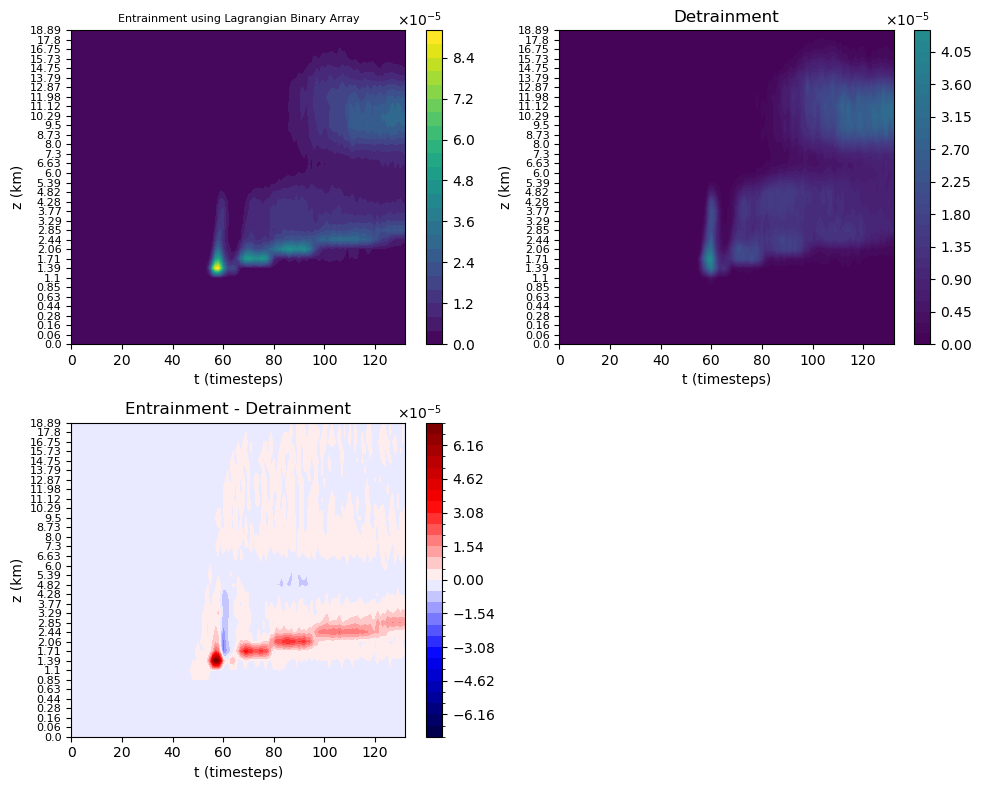

In [28]:
PROCESSING=False
# PROCESSING=True

type='general'
type='cloudy'

if PROCESSING==False:
    dir3=dir+f'Project_Algorithms/Entrainment/2D_entrainmentdetrainment_profiles_{res}_{Np_str}.h5'
if PROCESSING==True:
    dir3=dir+f'Project_Algorithms/Entrainment/2D_entrainmentdetrainment_profiles_PREPROCESSING_{res}_{Np_str}.h5'
with h5py.File(dir3, "r") as h5f:
    profile_array_e_g = h5f["profile_array_e_g"][:]
    profile_array_e_c = h5f["profile_array_e_c"][:]
    profile_array_d_g = h5f["profile_array_d_g"][:]
    profile_array_d_c = h5f["profile_array_d_c"][:]

if type=='general':
    profile_array_e=profile_array_e_g
    profile_array_d=profile_array_d_g
if type=='cloudy':
    profile_array_e=profile_array_e_c
    profile_array_d=profile_array_d_c

#APPLY CONSTANTS TO ENTRAINMENT VALUE
##################################################
profile_array_e=apply_constant(profile_array_e,True)
# profile_array_e=apply_constant(profile_array_e,False) #TESTING
profile_array_d=apply_constant(profile_array_d,True)
# profile_array_d=apply_constant(profile_array_d,False) #TESTING
##################################################


import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import numpy as np

fig = plt.figure(figsize=(10, 8))
gs = GridSpec(2, 2, figure=fig)

######
cmap1 = plt.cm.viridis
cmap2 = plt.cm.seismic 
n_levels=29
######

######
vmax_shared = np.max([np.max(profile_array_e), np.max(profile_array_d)])
norm_shared = mcolors.Normalize(vmin=0, vmax=vmax_shared)
######

# First subplot: Entrainment
########################################
ax1 = fig.add_subplot(gs[0, 0])
# contour1 = ax1.contourf(profile_array_e.T, cmap=cmap1)
contour1 = ax1.contourf(profile_array_e.T, cmap=cmap1, norm=norm_shared, levels=n_levels)
cbar1=fig.colorbar(contour1, ax=ax1)
Nz = len(data['zh'])
ax1.set_yticks(np.arange(Nz))
new_ytick_labels = np.round(data['zf'].values[:Nz], 2)
ax1.set_yticklabels(new_ytick_labels, fontsize=8, rotation=0)
ax1.set_ylabel('z (km)');ax1.set_xlabel('t (timesteps)')
ax1.set_title('Entrainment using Lagrangian Binary Array',fontsize=8)

# Second subplot: Detrainment
########################################
ax2 = fig.add_subplot(gs[0, 1])
# contour2 = ax2.contourf(profile_array_d.T, cmap=cmap1)
contour2 = ax2.contourf(profile_array_d.T, cmap=cmap1, norm=norm_shared, levels=n_levels)
cbar2 = fig.colorbar(contour2, ax=ax2)
ax2.set_yticks(np.arange(Nz))
new_ytick_labels = np.round(data['zf'].values[:Nz], 2)
ax2.set_yticklabels(new_ytick_labels, fontsize=8, rotation=0)
ax2.set_ylabel('z (km)');ax2.set_xlabel('t (timesteps)')
ax2.set_title('Detrainment')

# Third subplot: Net Entrainment
########################################
profile_array_net=profile_array_e-profile_array_d

# #OLD METHOD, DOESNT BALANCE COLOR LEVELS
# # Normalize with a balanced vmin and vmax
# levels=49; vmin=np.min(profile_array_net);vmax=np.max(profile_array_net)
# # vmin=-np.max(abs(profile_array_net)); vmax=+np.max(abs(profile_array_net))
# norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

# Normalize with a balanced vmin and vmax
vmin=-np.max(abs(profile_array_net)); vmax=+np.max(abs(profile_array_net))
levels = np.linspace(vmin, vmax, n_levels)
norm = mcolors.BoundaryNorm(boundaries=levels, ncolors=256)
cmap = plt.get_cmap('RdBu_r', n_levels)

ax3 = fig.add_subplot(gs[1, 0])
contour3 = ax3.contourf((profile_array_net).T, cmap=cmap2, norm=norm, levels=levels)
# contour3 = ax3.contourf((profile_array_net).T, cmap=cmap2, levels=30,vmin=-np.max(abs(profile_array_net)), vmax=+np.max(abs(profile_array_net)))
# cmap2 = plt.get_cmap('RdBu', 29);contour3 = ax3.pcolor(profile_array_net.T, cmap=cmap2, norm=norm, shading='auto')
cbar3 = fig.colorbar(contour3, ax=ax3, norm=norm)

#FIXING TICKS
ax3.set_yticks(np.arange(Nz))
new_ytick_labels = np.round(data['zf'].values[:Nz], 2)
ax3.set_yticklabels(new_ytick_labels, fontsize=8, rotation=0)
ax3.set_ylabel('z (km)');ax3.set_xlabel('t (timesteps)')
ax3.set_title('Entrainment - Detrainment')

#FIXING SCIENTIFIC NOTATION
from matplotlib.ticker import ScalarFormatter
formatter = ScalarFormatter(useMathText=True)
formatter.set_powerlimits((-2, 2))  # Adjust the range for scientific notation
for cbar in (cbar1,cbar2, cbar3):  # These must be Colorbar instances
    cbar.formatter = formatter
    cbar.update_ticks()

# Display the plot
plt.tight_layout()

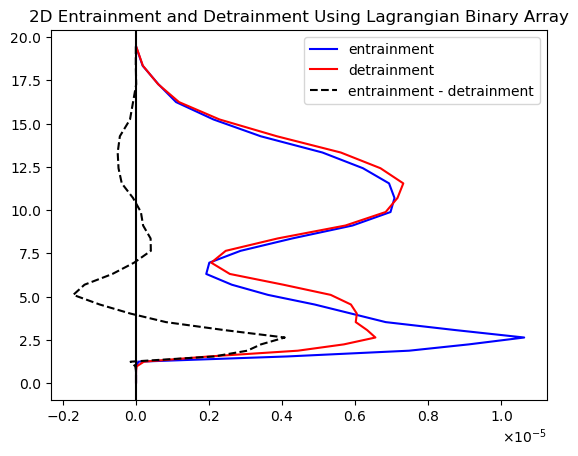

In [29]:
plt.plot(np.mean(profile_array_e,axis=(0)),data['zh'],color='blue',label='entrainment')
plt.plot(np.mean(profile_array_d,axis=(0)),data['zh'],color='red',label='detrainment')
plt.plot(np.mean(profile_array_e-profile_array_d,axis=(0)),data['zh'],linestyle='dashed',color='black',label='entrainment - detrainment')
plt.axvline(0,color='black')

plt.legend(); plt.title('2D Entrainment and Detrainment Using Lagrangian Binary Array')

from matplotlib.ticker import ScalarFormatter
formatter = ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((-1, 1))
plt.gca().xaxis.set_major_formatter(formatter)

In [33]:
# # SUMMING AND DIVIDING BY CORRECT CONSTANT IS SAME AS TAKING THE MEAN
# correction=1
# dt=300;Lt=130*5*60
# correction=dt/Lt

# plt.plot(np.sum(profile_array_e,axis=(0))*correction,data['zh'],color='blue',label='entrainment')
# plt.plot(np.sum(profile_array_d,axis=(0))*correction,data['zh'],color='red',label='detrainment')
# plt.plot(np.sum(profile_array_e-profile_array_d,axis=(0))*correction,data['zh'],linestyle='dashed',color='black',label='entrainment - detrainment')
# plt.axvline(0,color='black')

# plt.legend(); plt.title('2D Entrainment and Detrainment Using Lagrangian Binary Array')

# from matplotlib.ticker import ScalarFormatter
# formatter = ScalarFormatter(useMathText=True)
# formatter.set_scientific(True)
# formatter.set_powerlimits((-1, 1))
# plt.gca().xaxis.set_major_formatter(formatter)